In [76]:
import geostatspy.GSLIB as GSLIB                          # Utilidades GSLIB y funciones envueltas
import geostatspy.geostats as geostats                    # GSLIB convertido a Python
import os                                                 # Para configurar el directorio de trabajo
import numpy as np                                        # Biblioteca de funciones matemáticas
import pandas as pd                                       # Biblioteca para manipulación de marcos de datos
import matplotlib.pyplot as plt                           # Biblioteca para salida gráfica
import scipy.stats                                        # Biblioteca de resumenes estadísticos y matemáticos
import random as rand
from sklearn.metrics import r2_score
#import pygeostat as gs
plt.rcParams.update(plt.rcParamsDefault)

os.chdir("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER") # ruta de ejecutables de GSLIB

%matplotlib inline

## SIMULACIÓN GEOESTADÍSTICA 

In [77]:
# Modeling parameters, the model grid, the random seed, the target distribution, and color bar
nx = 100; ny = 50; cell_size=10                             # grid number of cells and cell size

xmin = 0; ymin =0;                                          # grid origin

xmax = 1000; ymax = 500    # calculate the extent of model
seed = 17276365

vmin = 0; vmax = 1; cmap = plt.cm.jet                     # color min and max and using the plasma color map

In [78]:
# Make a truth model / unconditional simulation
va_mean = 2; va_stdev = 0.55; va_cmin = 0; va_cmax = 4
var = GSLIB.make_variogram(nug=0.0,nst=1,it1=1,cc1=1.0,azi1=90,hmaj1=800,hmin1=100)
V = GSLIB.sgsim_uncond(1,nx,ny,cell_size,seed,var,"u")
V = GSLIB.affine(V,va_mean,va_stdev)
df_zko = pd.DataFrame(V)
df11 = df_zko.stack().reset_index().rename(columns={"level_0": "Elevation[Z]", "level_1": "Este[X]", 0:"V"})
x = df11["Elevation[Z]"].iloc[::-1].reset_index()
df11["Elevation[Z]"] = x["Elevation[Z]"]
##############################################################################################################
grid_x = np.linspace(0,500, num=50, endpoint=False) #Coord. de origen x, coord. de termino x, nª de celdas x.
grid_y = np.linspace(0,1000, num=100, endpoint=False) #Coord. de origen y, coord. de termino y, nª de celdas y.
#En este caso la matriz es de 100 x 100 celdas.
gy = np.array(grid_y) #conversión a un array de numpy 
gx = np.array(grid_x) #conversión a un array de numpy 
yg, xg = np.meshgrid(grid_x, grid_y, indexing='ij') #Creación de la grilla (intersecciones en yg; xg)
x_g = xg.ravel() #aplanamiento de xg
y_g = yg.ravel() #aplanamiento de yg
d = {'X': x_g, 'Z': y_g} #Columnas con coordenadas X e Y.
df = pd.DataFrame(data=d) #Creación del dataframe 
h = df["Z"].iloc[::-1].reset_index()
df["Z"] = h["Z"]
df["V"] = df11["V"] #Traspaso de la columna VA al nuevo DataFrame.
df['UG'] = 0

# Aplicar la condición y asignar 1 a los valores de "UG" que cumplan la condición
df.loc[df['V'] >= 1.3, 'UG'] = 1

df.to_csv("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/sim_data_dh5.csv")
df.describe().T

,count,mean,std,min,25%,50%,75%,max
X,5000.0,495.0000,288.689571,0.000000,247.500000,495.000000,742.50000,990.000000
Z,5000.0,245.0000,144.323130,0.000000,120.000000,245.000000,370.00000,490.000000
V,5000.0,2.0000,0.550055,0.174816,1.660819,2.024653,2.35824,3.833224
UG,5000.0,0.8874,0.316135,0.000000,1.000000,1.000000,1.00000,1.000000


In [79]:
df.head()

count    5000.000000
mean        2.000000
std         0.550055
min         0.174816
25%         1.660819
50%         2.024653
75%         2.358240
max         3.833224
Name: V, dtype: float64

[]

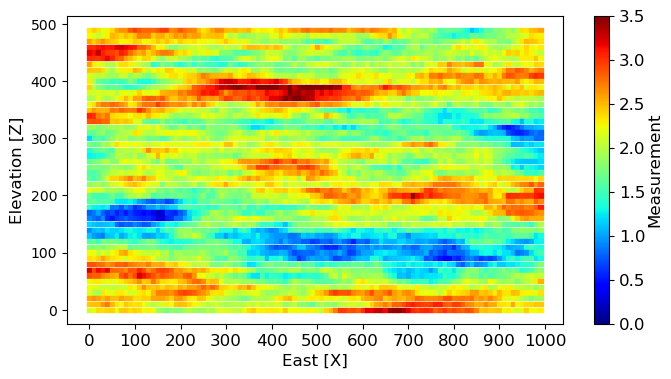

In [80]:
#plt.style.use('classic')

marker_size=10
fig = plt.figure(figsize=(8,4))
plt.scatter(df["X"], df["Z"], marker_size, df["V"], cmap = plt.cm.jet, marker="s")
#plt.title("SGSIM+Affine Correction", fontsize=20)
plt.xlabel('East [X]', fontsize=12)
plt.ylabel('Elevation [Z]', fontsize=12)
plt.xticks(range(0, 1001, 100), fontsize=12)
plt.grid(False)
cbar = plt.colorbar()
plt.clim(0, 3.5)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Measurement', labelpad=+1, fontsize=12)

#plt.savefig("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/simulation_dh_paper.png", dpi=300)
plt.plot()

[]

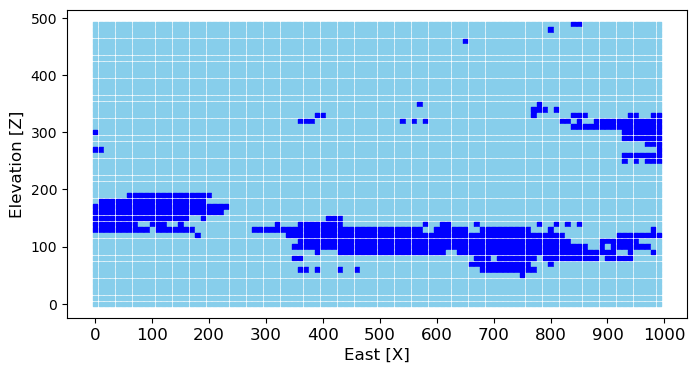

In [61]:
marker_size = 10
fig = plt.figure(figsize=(8, 4))
colors = ['blue' if u == 0 else 'skyblue' for u in df['UG']]
plt.scatter(df["X"], df["Z"], marker_size, c=colors, marker="s")
#plt.title("SGSIM+Affine Correction", fontsize=20)
plt.xlabel('East [X]', fontsize=12)
plt.ylabel('Elevation [Z]', fontsize=12)
plt.xticks(range(0, 1001, 100), fontsize=12)
plt.grid(False)
#plt.savefig("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/geology_dh_aniso.png", dpi=300)

plt.plot()


In [62]:
import numpy as np

valores_x = [50, 150, 250, 350, 450, 550, 650, 750, 850, 950]

# Filtrar los valores de X en el dataframe original
df_filtrado = df[df['X'].isin(valores_x)].copy()

# Eliminar las filas del dataframe donde los valores de X y Z cumplen la condición
for x in [250, 150, 750, 850]:
    df_filtrado = df_filtrado.loc[~((df_filtrado['X'] == x) & (df_filtrado['Z'] <= 150))]
    
for x in [50]:
    df_filtrado = df_filtrado.loc[~((df_filtrado['X'] == x) & (df_filtrado['Z'] <= 50))]

df_filtrado.to_csv("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/sample_dh_aniso.csv")

df_filtrado.describe().T


,count,mean,std,min,25%,50%,75%,max
X,430.0,506.279070,281.926632,50.000000,250.000000,550.000000,750.000000,950.000000
Z,430.0,273.372093,134.741490,0.000000,170.000000,280.000000,390.000000,490.000000
V,430.0,2.010360,0.548217,0.174816,1.693219,2.029029,2.326681,3.566789
UG,430.0,0.897674,0.303429,0.000000,1.000000,1.000000,1.000000,1.000000


## EXTRACCIÓN MUESTRA 

[]

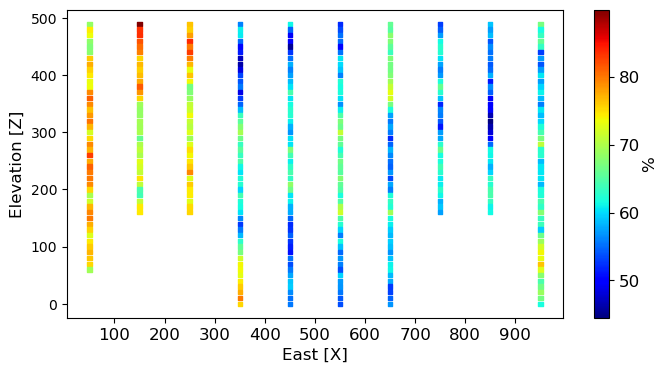

In [49]:
cmap = plt.cm.jet
fig = plt.figure(figsize=(8,4))
plt.scatter(df_filtrado["X"], df_filtrado["Z"], marker_size,df_filtrado["V"], cmap = cmap, marker="s")
#plt.title("Drillholes spacing 150 m", fontsize=20)
plt.xlabel('East [X]', fontsize=12)
plt.ylabel('Elevation [Z]', fontsize=12)
plt.xticks(range(0, 1001, 100), fontsize=12)
plt.grid(False)
cbar = plt.colorbar()
#plt.clim(0, 3.5)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('%', labelpad=+1, fontsize=12)

plt.savefig("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/dh_sample_aniso.png", dpi=300)
plt.plot()

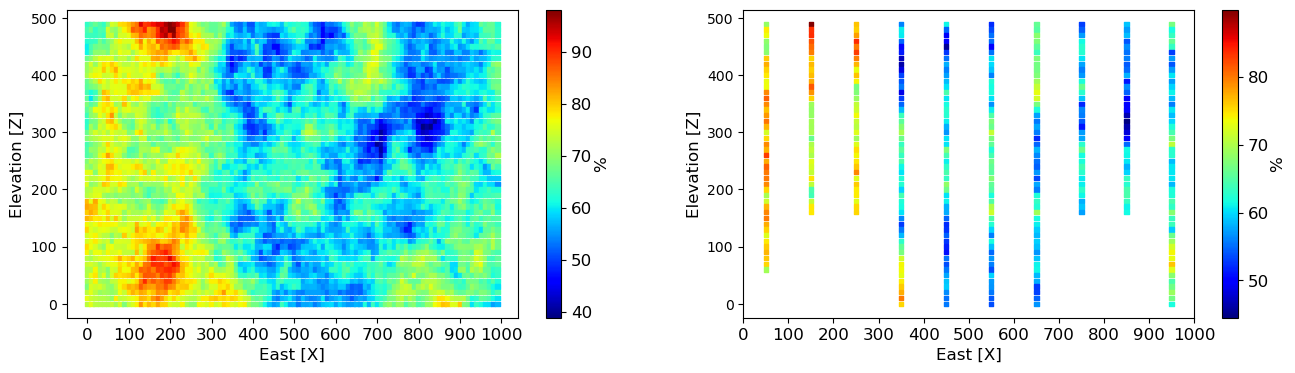

In [51]:
fig = plt.figure(figsize=(16,4))
plt.subplot(121)
plt.scatter(df["X"], df["Z"], marker_size, df["V"], cmap = cmap, marker="s")
#plt.title("SGSIM+Affine Correction", fontsize=20)
plt.xlabel('East [X]', fontsize=12)
plt.ylabel('Elevation [Z]', fontsize=12)
plt.xticks(range(0, 1001, 100), fontsize=12)
plt.grid(False)
cbar = plt.colorbar()
#plt.clim(0, 3.5)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('%', labelpad=+1, fontsize=12)
plt.subplot(122)
plt.scatter(df_filtrado["X"], df_filtrado["Z"], marker_size,df_filtrado["V"], cmap = cmap, marker="s")
#plt.title("Drillholes spacing 150 m", fontsize=20)
plt.xlabel('East [X]', fontsize=12)
plt.ylabel('Elevation [Z]', fontsize=12)
plt.xticks(range(0, 1001, 100), fontsize=12)
plt.grid(False)
cbar = plt.colorbar()
#plt.clim(0, 3.5)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('%', labelpad=+1, fontsize=12)
#plt.savefig("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/figure_sim_sample.png", dpi=300)

plt.show()

## KRIGING ORDINARIO

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Estandarizar la variable 'V'
df_filtrado['V1'] = scaler.fit_transform(df_filtrado[['V']])
df_filtrado.head()

,X,Z,V,UG,V1
5,50.0,490.0,0.973041,0,-2.103154
15,150.0,490.0,1.683987,1,-0.743758
25,250.0,490.0,1.638244,1,-0.831222
35,350.0,490.0,1.561828,1,-0.977337
45,450.0,490.0,0.648613,0,-2.723490


In [11]:
#df['V1'] = scaler.fit_transform(df[['V']]) #para el variograma de la simulación

In [12]:
lag000, vario000, npp000 = GSLIB.gamv_2d(df_filtrado,'X','Z','V1',20,50,0,12.5,50)
lag090, vario090, npp090 = GSLIB.gamv_2d(df_filtrado,'X','Z','V1',20,50,90,12.5,50)
lag045, vario045, npp045, = GSLIB.gamv_2d(df_filtrado,'X','Z','V1',20,50,45,12.5,50)
lag0135, vario0135, npp0135 = GSLIB.gamv_2d(df_filtrado,'X','Z','V1',20,50,135,12.5,50)
lagiso, varioiso, nppiso = GSLIB.gamv_2d(df_filtrado,'X','Z','V1',20,50,0,90,1)

fig = plt.figure(figsize=(8,4))
plt.scatter(lag000,vario000,s=25,marker='o',color = 'blue',label = 'Vertical')
plt.scatter(lag090,vario090,s=25,marker='o',color = 'red',label = 'Horizontal')

plt.plot([200,200],[0,1],color = 'black', label="Range", linestyle='dashed')

plt.plot([0,1000],[1,1],color = 'orange',label = 'Statistics Variance', linestyle='dashed')

plt.plot([200,1000],[1,1],color = 'black',label = 'Fitting model')
x = np.arange(0,200,1)
y = ((1.5*(x/200)) - (0.5*(x/200)**3))*1
plt.plot(x,y, color = 'black')
plt.xlabel('Lag distance (m)')
plt.ylabel('Semivariogram')
#plt.title('Semi-Variogram')
plt.ylim(0,2)
plt.xlim(0,1000)
handles, labels = plt.gca().get_legend_handles_labels()
plt.gca().legend(handles[::], labels[::])


plt.savefig("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/experimental_10_percent_paper.png", dpi=300)

plt.show()

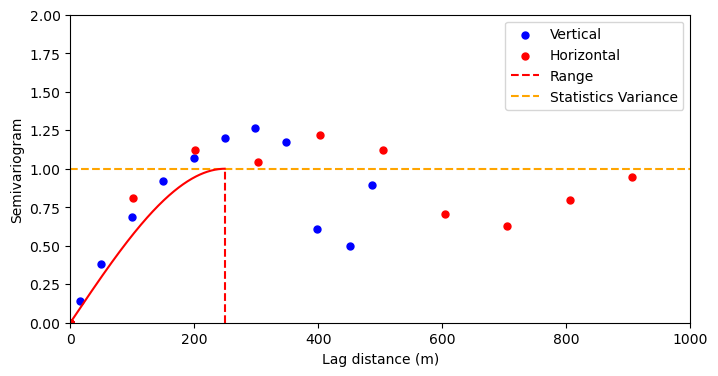

In [13]:
fig = plt.figure(figsize=(8,4))
plt.scatter(lag000,vario000,s=25,marker='o',color = 'blue',label = 'Vertical')
plt.scatter(lag090,vario090,s=25,marker='o',color = 'red',label = 'Horizontal')

plt.plot([250,250],[0,1],color = 'red', label="Range", linestyle='dashed')
#plt.plot([50,50],[0,1],color = 'blue', label="Range horizontal", linestyle='dashed')

plt.plot([0,1000],[1,1],color = 'orange',label = 'Statistics Variance', linestyle='dashed')

#plt.plot([300,1000],[1,1],color = 'red',label = 'Fitting model')
x = np.arange(0,250,1)
y = ((1.5*(x/250)) - (0.5*(x/250)**3))*1
plt.plot(x,y, color = 'red')
plt.xlabel('Lag distance (m)')
plt.ylabel('Semivariogram')
#plt.title('Semi-Variogram')
plt.ylim(0,2)
plt.xlim(0,1000)
handles, labels = plt.gca().get_legend_handles_labels()
plt.gca().legend(handles[::], labels[::])

#plt.plot([50,300],[1,1],color = 'blue',label = 'Fitting model 5% sample')
#x = np.arange(0,50,1)
#y = ((1.5*(x/50)) - (0.5*(x/50)**3))*1
#plt.plot(x,y, color = 'blue')
#plt.xlabel('Lag distance (m)')
#plt.ylabel('Semivariogram')


plt.savefig("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/experimental_380.png", dpi=300)

plt.show()

In [14]:
vario_kri = GSLIB.make_variogram(nug=0.0,nst=1,it1=1,cc1=1,azi1=0,hmaj1=250,hmin1=250) #ajuste con un unico modelo esférico 

In [15]:
nx = 100; ny=50; xsiz=10; ysiz=10; xmn=0; ymn= 0; ndmax=20; ndmin=1;radius=250; 

ktype=1; skmean=0; nxdis=1; nydis=1; tmin=-9999; tmax=9999

kmap, vmap = geostats.kb2d(df_filtrado, "X", "Z", "V1", tmin, tmax, nx, xmn, xsiz, ny, ymn, ysiz, nxdis, nydis, ndmin, ndmax, radius, ktype, skmean, vario_kri)

  Estimated   5000 blocks 
      average   -0.1072636175733065  variance  0.7275475133158961


In [16]:
xmin = 0; ymin =0;                                          # grid origin

xmax = 1000; ymax = 500    # calculate the extent of model

#GSLIB.pixelplt_st(kmap,xmin,xmax,ymin,ymax,1,0,3.5,"Mapa Kriging Ordinario", "Este [X]", "Norte [Y]", "Unidad de medida variable VA", cmap)

In [17]:
df_kmap = pd.DataFrame(kmap) #se pasan los valores estimados al dataframe de la simulación 
df_kmap = df_kmap.stack().reset_index().rename(columns={"level_0": "Elevation [Z]", "level_1": "East[X]", 0:"Ore grade"})

df["V_OKt"]= df_kmap["Ore grade"]
df.head()

,X,Z,V,UG,V_OKt
0,0.0,490.0,1.425655,1,-2.099794
1,10.0,490.0,1.398962,1,-2.203035
2,20.0,490.0,1.188708,0,-2.270757
3,30.0,490.0,0.992036,0,-2.367688
4,40.0,490.0,0.680945,0,-2.397128


In [18]:
df['V_OK'] = scaler.inverse_transform(df[['V_OKt']])
df.head()

,X,Z,V,UG,V_OKt,V_OK
0,0.0,490.0,1.425655,1,-2.099794,0.974798
1,10.0,490.0,1.398962,1,-2.203035,0.920804
2,20.0,490.0,1.188708,0,-2.270757,0.885387
3,30.0,490.0,0.992036,0,-2.367688,0.834693
4,40.0,490.0,0.680945,0,-2.397128,0.819296


[]

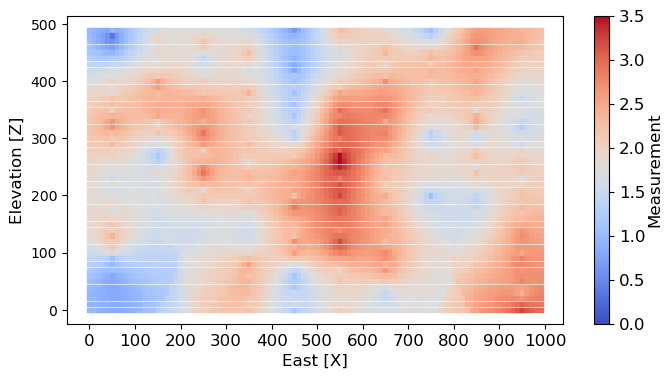

In [19]:
fig = plt.figure(figsize=(8,4))
plt.scatter(df["X"], df["Z"], marker_size, df["V_OK"], cmap = cmap, marker="s")
#plt.title("Ore Grade Estimated OK")
plt.xlabel('East [X]', fontsize=12)
plt.ylabel('Elevation [Z]', fontsize=12)
plt.xticks(range(0, 1001, 100), fontsize=12)
plt.grid(False)
cbar = plt.colorbar()
plt.clim(0, 3.5)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Measurement', labelpad=+1, fontsize=12)
plt.savefig("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/kriging_dh_380.png", dpi=300)
plt.plot()

(-0.3, 3.9)

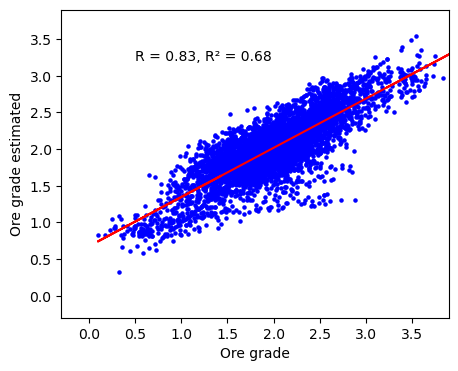

In [20]:
x = df["V"] 
y = df["V_OK"] 
slope, intercept = np.polyfit(x, y, 1)
regression_line = slope * x + intercept
r2 = r2_score(y, regression_line)
r = np.corrcoef(x, y)[0, 1]

fig = plt.figure(figsize=(5,4))
plt.scatter(x, y, color='blue', s=5, label='Data Points')
#plt.title("Validation OK", fontsize=12)
plt.plot(x, regression_line, color='red', label='Regression Line')
plt.text(0.5,3.2, 'R = {:.2f}, R\u00b2 = {:.2f}'.format(r, r2))
plt.xlabel("Ore grade")
plt.ylabel("Ore grade estimated")
plt.xlim((-0.3,3.9))
plt.ylim((-0.3,3.9))
#plt.savefig("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/dh_validation_ok_10percent.png", dpi=300)

In [21]:
def calculate_mse(dataframe, target_column, predicted_column):
    # Extract the target and predicted columns from the DataFrame
    target = dataframe[target_column]
    predicted = dataframe[predicted_column]

    # Calculate the squared differences between the target and predicted values
    squared_diff = np.square(target - predicted)

    # Calculate the mean squared error
    mse = np.mean(squared_diff)

    return mse

# Example usage
# Assuming you have a DataFrame named 'data' with columns 'target' and 'predicted'
mse_score = calculate_mse(df, 'V', 'V_OK')
print("Mean Squared Error:", mse_score)

Mean Squared Error: 0.0961749578637252


In [22]:
def calculate_mae(dataframe, target_column, predicted_column):
    # Extract the target and predicted columns from the DataFrame
    target = dataframe[target_column]
    predicted = dataframe[predicted_column]

    # Calculate the absolute differences between the target and predicted values
    abs_diff = np.abs(target - predicted)

    # Calculate the mean absolute error
    mae = np.mean(abs_diff)

    return mae

# Example usage
# Assuming you have a DataFrame named 'data' with columns 'target' and 'predicted'
mae_score = calculate_mae(df, 'V', 'V_OK')
print("Mean Absolute Error:", mae_score)

Mean Absolute Error: 0.23444449250913785


In [25]:
df.to_csv("C:/Users/nubem/Documents/NUBEMINERA_2020/GSLIB_FOLDER/data/dataset_ok.csv")